# RheolNet — Task 1.1 Kaggle Integration Notebook

## Goal

This notebook is the **experiment / verification layer** for:

> **Task 1.1 — Integrate Carreau–Yasuda viscosity into the Navier–Stokes PDE residuals**

The reusable implementation should live in the repository:

```text
RheolNet/
├── models/
│   └── pinn_core.py
├── physics/
│   ├── carreau_yasuda.py
│   ├── navier_stokes.py
│   └── tests/
│       ├── test_carreau_yasuda.py
│       └── test_navier_stokes_nonnewtonian.py
└── training/
    └── loss_functions.py
```

The notebook intentionally **does not redefine** `PINN`, `carreau_yasuda_viscosity`, or
`compute_ns_residuals_nonnewtonian`. It imports and exercises the real `.py` code.

### What this notebook does

1. Optional P100-compatible PyTorch installation
2. Locate/clone the RheolNet repository
3. Add RheolNet to `sys.path` and enable autoreload
4. Import and verify the actual `.py` modules
5. Require a working CUDA GPU rather than silently using CPU
6. Configure the CY/PINN experiment
7. Create the model and optimizer
8. Smoke-test the non-Newtonian residual before training
9. Load/save GPU-safe checkpoints
10. Train using the imported CY Navier–Stokes residual
11. Plot loss, velocity, pressure, viscosity, and shear rate
12. Inspect 2D fields
13. Run the automated tests
14. Print a Task 1.1 completion checklist

---

### Expected `.py` interfaces

This notebook expects:

```python
from models.pinn_core import PINN

from physics.carreau_yasuda import carreau_yasuda_viscosity

from physics.navier_stokes import compute_ns_residuals_nonnewtonian

from training.loss_functions import navier_stokes_physics_loss
```

and the non-Newtonian residual should be callable as:

```python
continuity, momentum_x, momentum_y, eta, gamma_dot = (
    compute_ns_residuals_nonnewtonian(
        model=model,
        xy=xy,
        rho=...,
        eta0=...,
        eta_inf=...,
        lam=...,
        n=...,
        a=...,
    )
)
```

## Cell 0 — Optional Tesla P100 PyTorch setup

A Tesla P100 is a Pascal GPU (`sm_60`). If your current Kaggle PyTorch build does not
contain `sm_60` kernels, set `RUN_P100_INSTALL = True` and run this cell **once**.

After installation:

1. Restart the Kaggle session/kernel.
2. Set `RUN_P100_INSTALL = False`.
3. Continue from the repository/import cells.

Do **not** repeatedly reinstall PyTorch on every run.

In [ ]:
# ===============================================================
# CELL 0 — OPTIONAL P100-COMPATIBLE PYTORCH INSTALL
# ===============================================================

RUN_P100_INSTALL = False

if RUN_P100_INSTALL:
    import subprocess
    import sys

    commands = [
        [
            sys.executable, "-m", "pip", "uninstall", "-y",
            "torch", "torchvision", "torchaudio"
        ],
        [
            sys.executable, "-m", "pip", "install", "--no-cache-dir",
            "torch==2.8.0",
            "torchvision==0.23.0",
            "torchaudio==2.8.0",
            "--index-url",
            "https://download.pytorch.org/whl/cu126"
        ],
    ]

    for command in commands:
        print("Running:", " ".join(command))
        subprocess.check_call(command)

    print()
    print("=" * 72)
    print("INSTALLATION FINISHED")
    print("RESTART THE KAGGLE SESSION NOW")
    print("After restart, set RUN_P100_INSTALL = False")
    print("=" * 72)

else:
    print("P100 installation cell skipped.")

## Cell 1 — Locate the repository

If you already placed the repository in `/kaggle/working/RheolNet`, nothing will be
downloaded.

If it is missing, the cell can clone the `Atharva_pinn-core-baseline` branch.

`PULL_LATEST` defaults to `False` so local Kaggle edits are not overwritten unexpectedly.

In [1]:
# ===============================================================
# REPOSITORY LOCATION / OPTIONAL CLONE
# ===============================================================

from pathlib import Path
import subprocess
import os

REPO_DIR = Path("/kaggle/working/RheolNet")
BRANCH = "Atharva_pinn-core-baseline"

CLONE_IF_MISSING = True
PULL_LATEST = False

if not REPO_DIR.exists():
    if not CLONE_IF_MISSING:
        raise FileNotFoundError(
            f"RheolNet was not found at {REPO_DIR}. "
            "Either place the repo there or set CLONE_IF_MISSING=True."
        )

    print("RheolNet repository not found. Cloning branch:", BRANCH)

    subprocess.check_call([
        "git", "clone",
        "--branch", BRANCH,
        "--single-branch",
        "https://github.com/ath4trva/RheolNet.git",
        str(REPO_DIR),
    ])

else:
    print("Using existing RheolNet repository:", REPO_DIR)

if PULL_LATEST:
    print("Pulling latest branch changes...")
    subprocess.check_call(
        ["git", "pull", "origin", BRANCH],
        cwd=str(REPO_DIR),
    )

print("Repository location:", REPO_DIR)
print("Exists:", REPO_DIR.exists())

Using existing RheolNet repository: /kaggle/working/RheolNet
Repository location: /kaggle/working/RheolNet
Exists: True


## Cell 2 — Python path + automatic module reload

Adding the repository root to `sys.path` makes imports such as
`from physics.navier_stokes import ...` work.

`%autoreload 2` is helpful during development: after editing a `.py` file, Jupyter will
usually use the updated code without a full kernel restart.

In [2]:
# ===============================================================
# PYTHON PATH
# ===============================================================

import sys

repo_str = str(REPO_DIR)

if repo_str not in sys.path:
    sys.path.insert(0, repo_str)

print("RheolNet added to sys.path:")
print(sys.path[0])

RheolNet added to sys.path:
/kaggle/working/RheolNet


## Cell 3 — Import the actual RheolNet implementation

If this cell fails, fix the `.py` file first instead of copying the function back into the notebook.

In [3]:
# ===============================================================
# STANDARD IMPORTS
# ===============================================================

import math
import random
import os
import inspect
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

torch.set_default_dtype(torch.float32)

# ===============================================================
# RHEOLNET IMPORTS
# ===============================================================

try:
    from models.pinn_core import PINN

    from physics.carreau_yasuda import (
        carreau_yasuda_viscosity,
    )

    from physics.navier_stokes import (
        compute_ns_residuals_nonnewtonian,
    )

    from training.loss_functions import (
        navier_stokes_physics_loss,
    )

except Exception as exc:
    print("=" * 72)
    print("RHEOLNET IMPORT FAILED")
    print("=" * 72)
    print(type(exc).__name__ + ":", exc)
    print()
    print("Expected files/functions:")
    print("  models/pinn_core.py -> PINN")
    print("  physics/carreau_yasuda.py -> carreau_yasuda_viscosity")
    print("  physics/navier_stokes.py -> compute_ns_residuals_nonnewtonian")
    print("  training/loss_functions.py -> navier_stokes_physics_loss")
    print()
    print("Fix the .py implementation, then rerun this cell.")
    raise

print("✓ RheolNet modules imported successfully")
print("PyTorch:", torch.__version__)

✓ RheolNet modules imported successfully
PyTorch: 2.8.0+cu126


## Cell 4 — Verify exactly which files Kaggle imported

This prevents a common Jupyter problem: accidentally running an old copied function or a module
from the wrong folder.

The residual signature should include both `model` and `xy`.

In [4]:
# ===============================================================
# IMPORT / INTERFACE VERIFICATION
# ===============================================================

print("=" * 72)
print("RHEOLNET IMPORT CHECK")
print("=" * 72)

objects = {
    "PINN": PINN,
    "Carreau-Yasuda": carreau_yasuda_viscosity,
    "Navier-Stokes residual": compute_ns_residuals_nonnewtonian,
    "Physics loss": navier_stokes_physics_loss,
}

for name, obj in objects.items():
    print(f"{name}:")
    print("  file:", inspect.getfile(obj))

    try:
        print("  signature:", inspect.signature(obj))
    except (TypeError, ValueError):
        pass

    print()

ns_signature = inspect.signature(
    compute_ns_residuals_nonnewtonian
)

ns_params = set(ns_signature.parameters)

required_ns_params = {"model", "xy"}

missing = required_ns_params - ns_params

if missing:
    raise RuntimeError(
        "physics/navier_stokes.py is using the old interface. "
        f"Missing parameters: {sorted(missing)}. "
        "The residual function must explicitly receive model and xy."
    )

required_files = [
    REPO_DIR / "models" / "pinn_core.py",
    REPO_DIR / "physics" / "carreau_yasuda.py",
    REPO_DIR / "physics" / "navier_stokes.py",
    REPO_DIR / "training" / "loss_functions.py",
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(file_path)

print("✓ Required files exist")
print("✓ Navier-Stokes function explicitly receives model and xy")
print("=" * 72)

RHEOLNET IMPORT CHECK
PINN:
  file: /kaggle/working/RheolNet/models/pinn_core.py
  signature: (in_dim=2, out_dim=3, hidden_layers=4, hidden_width=64)

Carreau-Yasuda:
  file: /kaggle/working/RheolNet/physics/carreau_yasuda.py
  signature: (gamma_dot, eta0=0.056, eta_inf=0.0035, lam=3.313, n=0.3568, a=2.0)

Navier-Stokes residual:
  file: /kaggle/working/RheolNet/physics/navier_stokes.py
  signature: (model, xy, rho=1.0, eta0=0.056, eta_inf=0.0035, lam=3.313, n=0.3568, a=2.0, eps=1e-12)

Physics loss:
  file: /kaggle/working/RheolNet/training/loss_functions.py
  signature: (continuity, momentum_x, momentum_y)

✓ Required files exist
✓ Navier-Stokes function explicitly receives model and xy


## Cell 5 — Strict GPU / P100 verification

This notebook is intended to train on GPU. It **does not silently fall back to CPU**.

A real matrix multiplication is executed because `torch.cuda.is_available()` by itself does not
prove that the installed PyTorch binary contains kernels for the detected GPU.

In [5]:
# ===============================================================
# STRICT CUDA CHECK
# ===============================================================

import torch

print("=" * 72)
print("RHEOLNET GPU CHECK")
print("=" * 72)

print("PyTorch version :", torch.__version__)
print("CUDA runtime    :", torch.version.cuda)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Enable a Kaggle GPU accelerator."
    )

gpu_name = torch.cuda.get_device_name(0)
major, minor = torch.cuda.get_device_capability(0)
gpu_arch = f"sm_{major}{minor}"
built_arches = torch.cuda.get_arch_list()

print("GPU             :", gpu_name)
print("Compute cap.    :", f"{major}.{minor}")
print("Architecture    :", gpu_arch)
print("Built arches    :", built_arches)

if gpu_arch not in built_arches and f"compute_{major}{minor}" not in built_arches:
    raise RuntimeError(
        f"GPU {gpu_name} requires {gpu_arch}, but this PyTorch build "
        "does not contain that architecture."
    )

device = torch.device("cuda:0")
torch.cuda.set_device(0)

# Real CUDA execution test
a_test = torch.randn(256, 256, device=device)
b_test = torch.randn(256, 256, device=device)
c_test = a_test @ b_test

torch.cuda.synchronize()

del a_test, b_test, c_test
torch.cuda.empty_cache()

print("CUDA kernel test: PASSED")
print("Training device :", device)

if "P100" in gpu_name.upper():
    print("Tesla P100      : CONFIRMED")
else:
    print("Note: CUDA works, but the current GPU is not reported as a P100.")

print("=" * 72)

RHEOLNET GPU CHECK
PyTorch version : 2.8.0+cu126
CUDA runtime    : 12.6
GPU             : Tesla P100-PCIE-16GB
Compute cap.    : 6.0
Architecture    : sm_60
Built arches    : ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
CUDA kernel test: PASSED
Training device : cuda:0
Tesla P100      : CONFIRMED


## Cell 6 — Reproducibility

The seed is applied to Python, NumPy, CPU PyTorch, and CUDA.

In [6]:
# ===============================================================
# REPRODUCIBILITY
# ===============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Seed:", SEED)

Seed: 42


## Cell 7 — Experiment configuration

### Important scientific note

This notebook keeps the **Day-1 normalized unit channel** (`x,y ∈ [0,1]`) so Task 1.1 can be
debugged cleanly. The CY parameters are blood-like values, but the complete experiment is **not yet
a quantitatively dimensional artery simulation** because geometry, velocity, pressure, density,
and rheology have not all been nondimensionalized together.

Use this notebook to validate **software integration and physics behavior**. Later, move to a
consistent dimensional or nondimensional formulation for publication-quality validation.

In [7]:
# ===============================================================
# CONFIGURATION
# ===============================================================

@dataclass
class Config:
    # Domain
    x_min: float = 0.0
    x_max: float = 1.0
    y_min: float = 0.0
    y_max: float = 1.0

    # Sampling
    n_collocation: int = 1024
    n_boundary: int = 256

    # Training
    n_train_steps: int = 2000
    learning_rate: float = 1e-3
    boundary_weight: float = 10.0
    save_every: int = 500
    print_every: int = 100

    # Network
    hidden_layers: int = 4
    hidden_width: int = 64

    # Inlet experiment
    inlet_u_max: float = 1.0

    # Normalized flow density for this integration experiment
    rho: float = 1.0

    # Carreau-Yasuda
    eta0: float = 0.056
    eta_inf: float = 0.0035
    lam: float = 3.313
    n: float = 0.3568
    a: float = 2.0

cfg = Config()

print("Configuration")
for key, value in asdict(cfg).items():
    print(f"{key:18s}: {value}")

Configuration
x_min             : 0.0
x_max             : 1.0
y_min             : 0.0
y_max             : 1.0
n_collocation     : 1024
n_boundary        : 256
n_train_steps     : 2000
learning_rate     : 0.001
boundary_weight   : 10.0
save_every        : 500
print_every       : 100
hidden_layers     : 4
hidden_width      : 64
inlet_u_max       : 1.0
rho               : 1.0
eta0              : 0.056
eta_inf           : 0.0035
lam               : 3.313
n                 : 0.3568
a                 : 2.0


## Cell 8 — Create the PINN and optimizer

The neural-network definition comes from `models/pinn_core.py`.

In [8]:
# ===============================================================
# MODEL + OPTIMIZER
# ===============================================================

model = PINN(
    in_dim=2,
    out_dim=3,
    hidden_layers=cfg.hidden_layers,
    hidden_width=cfg.hidden_width,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg.learning_rate,
)

mse = nn.MSELoss()

n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)
print()
print("Trainable parameters:", n_params)
print("Model device:", next(model.parameters()).device)

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)

Trainable parameters: 12867
Model device: cuda:0


## Cell 9 — Physics smoke test before training

This is deliberately run **before** a long training loop.

It checks that:

- the model can be evaluated;
- first/second autograd paths work;
- the residual returns 5 fields;
- shapes are `[N,1]`;
- viscosity and shear rate are finite;
- the imported physics-loss function accepts the residuals.

If this cell fails, fix the `.py` physics code before training.

In [9]:
# ===============================================================
# PHYSICS SMOKE TEST
# ===============================================================

xy_smoke = torch.rand(
    32,
    2,
    device=device,
    requires_grad=True,
)

outputs = compute_ns_residuals_nonnewtonian(
    model=model,
    xy=xy_smoke,
    rho=cfg.rho,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)

if not isinstance(outputs, (tuple, list)) or len(outputs) != 5:
    raise RuntimeError(
        "compute_ns_residuals_nonnewtonian must return exactly:\n"
        "(continuity, momentum_x, momentum_y, eta, gamma_dot)"
    )

(
    continuity_smoke,
    momentum_x_smoke,
    momentum_y_smoke,
    eta_smoke,
    gamma_smoke,
) = outputs

named_smoke = {
    "continuity": continuity_smoke,
    "momentum_x": momentum_x_smoke,
    "momentum_y": momentum_y_smoke,
    "eta": eta_smoke,
    "gamma_dot": gamma_smoke,
}

for name, tensor in named_smoke.items():
    if tensor.shape != (32, 1):
        raise RuntimeError(
            f"{name} has shape {tuple(tensor.shape)}; expected (32, 1)."
        )

    if not torch.isfinite(tensor).all():
        raise RuntimeError(
            f"{name} contains NaN or Inf."
        )

physics_loss_smoke = navier_stokes_physics_loss(
    continuity_smoke,
    momentum_x_smoke,
    momentum_y_smoke,
)

if physics_loss_smoke.ndim != 0:
    raise RuntimeError(
        "navier_stokes_physics_loss should return a scalar tensor."
    )

print("✓ Residual returns all 5 fields")
print("✓ Shapes are correct")
print("✓ No NaN / Inf")
print("✓ Physics loss is scalar")
print("Mean viscosity :", eta_smoke.detach().mean().item())
print("Mean shear rate:", gamma_smoke.detach().mean().item())

del xy_smoke, outputs
torch.cuda.empty_cache()

✓ Residual returns all 5 fields
✓ Shapes are correct
✓ No NaN / Inf
✓ Physics loss is scalar
Mean viscosity : 0.054024964570999146
Mean shear rate: 0.10696864873170853


## Cell 10 — GPU-safe checkpoint system

Key design choice:

- checkpoint tensors are loaded to **CPU first**;
- model weights are then placed on the P100;
- optimizer tensors are moved to the P100;
- CPU RNG state remains a CPU `torch.uint8` tensor;
- CUDA RNG state is restored separately.

This avoids the RNG-state error that occurs when `torch.set_rng_state()` receives a CUDA tensor.

In [11]:
# ===============================================================
# CHECKPOINT SYSTEM
# ===============================================================

CHECKPOINT_DIR = Path("/kaggle/working/rheolnet_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = CHECKPOINT_DIR / "task_1_1_cy_ns.pt"


def fresh_history():
    return {
        "total": [],
        "physics": [],
        "boundary": [],
        "continuity": [],
        "momentum_x": [],
        "momentum_y": [],
        "eta_mean": [],
        "gamma_mean": [],
    }


def get_rng_state():
    state = {
        "python_random": random.getstate(),
        "numpy_random": np.random.get_state(),
        "torch_random": torch.get_rng_state().cpu(),
    }

    if device.type == "cuda":
        state["torch_cuda_random"] = [
            s.cpu()
            for s in torch.cuda.get_rng_state_all()
        ]

    return state


def set_rng_state(state):
    if "python_random" in state:
        random.setstate(state["python_random"])

    if "numpy_random" in state:
        np.random.set_state(state["numpy_random"])

    if "torch_random" in state:
        cpu_rng = (
            state["torch_random"]
            .detach()
            .cpu()
            .to(dtype=torch.uint8)
        )
        torch.set_rng_state(cpu_rng)

    if device.type == "cuda" and "torch_cuda_random" in state:
        cuda_states = [
            s.detach().cpu().to(dtype=torch.uint8)
            for s in state["torch_cuda_random"]
            if torch.is_tensor(s)
        ]

        if torch.cuda.device_count() == 1 and len(cuda_states) >= 1:
            torch.cuda.set_rng_state(
                cuda_states[0],
                device=0,
            )
        elif len(cuda_states) == torch.cuda.device_count():
            torch.cuda.set_rng_state_all(cuda_states)


def move_optimizer_to_device(optimizer, target_device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(target_device)


def save_checkpoint(path, step, model, optimizer, history):
    payload = {
        "step": int(step),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "rng_state": get_rng_state(),
        "cfg": asdict(cfg),
    }

    torch.save(payload, path)

    print(
        f"Checkpoint saved: step={step} -> {path}"
    )


def load_checkpoint(path, model, optimizer):
    if not Path(path).exists():
        print("No checkpoint found — starting from step 0.")
        return 0, fresh_history()

    print("Loading checkpoint:", path)

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    try:
        model.load_state_dict(
            checkpoint["model_state_dict"]
        )
    except RuntimeError as exc:
        print()
        print("Checkpoint model architecture does not match the current PINN.")
        print("Rename/delete the old checkpoint if you intentionally changed the model.")
        raise exc

    model.to(device)

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    move_optimizer_to_device(
        optimizer,
        device,
    )

    if "rng_state" in checkpoint:
        try:
            set_rng_state(
                checkpoint["rng_state"]
            )
            print("RNG state restored.")
        except Exception as exc:
            print(
                "WARNING: RNG state could not be restored:",
                type(exc).__name__,
                exc,
            )
            print("Model/optimizer restoration is still valid.")

    history = checkpoint.get(
        "history",
        fresh_history(),
    )

    default = fresh_history()
    for key in default:
        history.setdefault(key, [])

    step = int(
        checkpoint.get("step", 0)
    )

    print("Checkpoint loaded.")
    print("Resume step :", step)
    print("Model device:", next(model.parameters()).device)

    return step, history

## Cell 11 — Load an existing checkpoint

Set `RESUME_FROM_CHECKPOINT = False` if you explicitly want a fresh Task 1.1 run.

In [12]:
# ===============================================================
# CHECKPOINT LOAD
# ===============================================================

RESUME_FROM_CHECKPOINT = True

if RESUME_FROM_CHECKPOINT:
    start_step, history = load_checkpoint(
        CHECKPOINT_PATH,
        model,
        optimizer,
    )
else:
    start_step = 0
    history = fresh_history()
    print("Fresh training run requested.")

print("Start step:", start_step)

No checkpoint found — starting from step 0.
Start step: 0


## Cell 12 — Sanity-check the Carreau–Yasuda curve

Before involving the PINN, verify the imported rheology function independently.

For a shear-thinning CY model with `n < 1`, viscosity should decrease from approximately
`eta0` at very low shear toward `eta_inf` at very high shear.

Low-shear viscosity : 0.05599981173872948
High-shear viscosity: 0.003785728244110942
eta0                : 0.056
eta_inf             : 0.0035


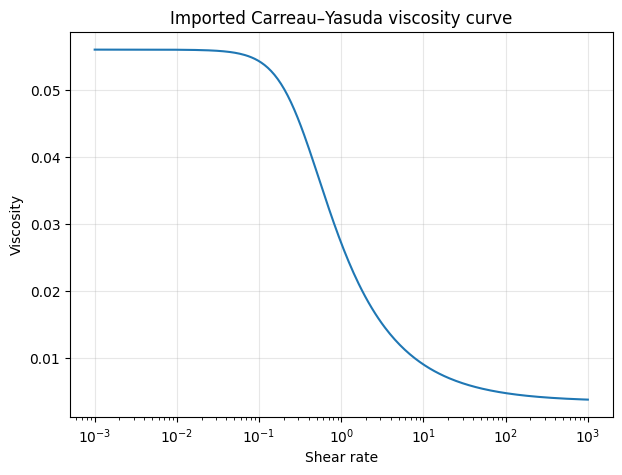

In [13]:
# ===============================================================
# CARREAU-YASUDA CURVE
# ===============================================================

gamma_curve = torch.logspace(
    -3,
    3,
    300,
    device=device,
)

with torch.no_grad():
    eta_curve = carreau_yasuda_viscosity(
        gamma_curve,
        eta0=cfg.eta0,
        eta_inf=cfg.eta_inf,
        lam=cfg.lam,
        n=cfg.n,
        a=cfg.a,
    )

gamma_np = gamma_curve.cpu().numpy()
eta_np = eta_curve.cpu().numpy()

print("Low-shear viscosity :", float(eta_np[0]))
print("High-shear viscosity:", float(eta_np[-1]))
print("eta0                :", cfg.eta0)
print("eta_inf             :", cfg.eta_inf)

if not eta_np[0] > eta_np[-1]:
    raise RuntimeError(
        "Expected shear-thinning behavior, but viscosity did not decrease."
    )

plt.figure(figsize=(7, 5))
plt.semilogx(gamma_np, eta_np)
plt.xlabel("Shear rate")
plt.ylabel("Viscosity")
plt.title("Imported Carreau–Yasuda viscosity curve")
plt.grid(True, alpha=0.3)
plt.show()

## Cell 13 — Interior sampling and boundary conditions

The old Day-1 parabola is **not used as an exact CY solution**.

Instead the experiment applies:

- **bottom wall:** `u = 0`, `v = 0`
- **top wall:** `u = 0`, `v = 0`
- **inlet:** prescribed parabolic velocity profile, `v = 0`
- **outlet:** gauge pressure `p = 0`

A prescribed parabolic inlet is a boundary condition, not a claim that the whole
non-Newtonian solution is analytically parabolic.

In [15]:
# ===============================================================
# SAMPLING
# ===============================================================

def sample_interior(n):
    x = torch.rand(
        n, 1,
        device=device,
    ) * (cfg.x_max - cfg.x_min) + cfg.x_min

    y = torch.rand(
        n, 1,
        device=device,
    ) * (cfg.y_max - cfg.y_min) + cfg.y_min

    xy = torch.cat(
        [x, y],
        dim=1,
    )

    return xy


def sample_boundary(n_total):
    n_side = max(1, n_total // 4)

    # Bottom wall
    x_bottom = torch.rand(n_side, 1, device=device)
    y_bottom = torch.full_like(x_bottom, cfg.y_min)
    bottom = torch.cat([x_bottom, y_bottom], dim=1)

    # Top wall
    x_top = torch.rand(n_side, 1, device=device)
    y_top = torch.full_like(x_top, cfg.y_max)
    top = torch.cat([x_top, y_top], dim=1)

    # Inlet
    y_inlet = torch.rand(n_side, 1, device=device)
    x_inlet = torch.full_like(y_inlet, cfg.x_min)
    inlet = torch.cat([x_inlet, y_inlet], dim=1)

    # Outlet
    y_outlet = torch.rand(n_side, 1, device=device)
    x_outlet = torch.full_like(y_outlet, cfg.x_max)
    outlet = torch.cat([x_outlet, y_outlet], dim=1)

    return {
        "bottom": bottom,
        "top": top,
        "inlet": inlet,
        "outlet": outlet,
    }


def inlet_target_u(y):
    # Unit-channel prescribed inlet profile.
    y_norm = (
        (y - cfg.y_min)
        / (cfg.y_max - cfg.y_min)
    )

    return (
        4.0
        * cfg.inlet_u_max
        * y_norm
        * (1.0 - y_norm)
    )


def compute_boundary_loss(model, n_boundary):
    bc = sample_boundary(n_boundary)

    bottom_pred = model(bc["bottom"])
    top_pred = model(bc["top"])
    inlet_pred = model(bc["inlet"])
    outlet_pred = model(bc["outlet"])

    zeros_bottom = torch.zeros_like(
        bottom_pred[:, 0:1]
    )
    zeros_top = torch.zeros_like(
        top_pred[:, 0:1]
    )
    zeros_inlet = torch.zeros_like(
        inlet_pred[:, 0:1]
    )
    zeros_outlet = torch.zeros_like(
        outlet_pred[:, 2:3]
    )

    # No-slip walls: u=v=0
    wall_loss = (
        mse(bottom_pred[:, 0:1], zeros_bottom)
        + mse(bottom_pred[:, 1:2], zeros_bottom)
        + mse(top_pred[:, 0:1], zeros_top)
        + mse(top_pred[:, 1:2], zeros_top)
    )

    # Prescribed inlet velocity
    inlet_u_target = inlet_target_u(
        bc["inlet"][:, 1:2]
    )

    inlet_loss = (
        mse(
            inlet_pred[:, 0:1],
            inlet_u_target,
        )
        + mse(
            inlet_pred[:, 1:2],
            zeros_inlet,
        )
    )

    # Pressure reference at outlet
    outlet_loss = mse(
        outlet_pred[:, 2:3],
        zeros_outlet,
    )

    total_bc_loss = (
        wall_loss
        + inlet_loss
        + outlet_loss
    )

    components = {
        "wall": wall_loss,
        "inlet": inlet_loss,
        "outlet": outlet_loss,
    }

    return total_bc_loss, components

## Cell 14 — Train with the imported **non-Newtonian Navier–Stokes residual**

This is the core Task 1.1 integration.

The training path is now:

```text
(x,y)
  ↓
PINN from models/pinn_core.py
  ↓
(u,v,p)
  ↓
physics/navier_stokes.py
  ↓
strain-rate tensor
  ↓
effective shear rate γ̇
  ↓
physics/carreau_yasuda.py
  ↓
local viscosity η(γ̇)
  ↓
non-Newtonian stress divergence
  ↓
continuity + x/y momentum residuals
  ↓
physics loss
  ↓
backpropagation
```

In [16]:
# ===============================================================
# TRAINING LOOP
# ===============================================================

RUN_TRAINING = True

if RUN_TRAINING:
    model.train()

    first_step = start_step + 1

    if first_step > cfg.n_train_steps:
        print(
            f"Checkpoint is already at step {start_step}, "
            f"which is >= n_train_steps={cfg.n_train_steps}."
        )
        print("Increase cfg.n_train_steps to continue training.")

    else:
        for step in range(
            first_step,
            cfg.n_train_steps + 1,
        ):
            optimizer.zero_grad(set_to_none=True)

            # -----------------------------------------------
            # Interior physics
            # -----------------------------------------------

            xy_f = sample_interior(
                cfg.n_collocation
            )

            (
                continuity,
                momentum_x,
                momentum_y,
                eta_field,
                gamma_dot_field,
            ) = compute_ns_residuals_nonnewtonian(
                model=model,
                xy=xy_f,
                rho=cfg.rho,
                eta0=cfg.eta0,
                eta_inf=cfg.eta_inf,
                lam=cfg.lam,
                n=cfg.n,
                a=cfg.a,
            )

            physics_loss = navier_stokes_physics_loss(
                continuity,
                momentum_x,
                momentum_y,
            )

            # Individual residual losses for diagnostics
            continuity_loss = torch.mean(
                continuity ** 2
            )

            momentum_x_loss = torch.mean(
                momentum_x ** 2
            )

            momentum_y_loss = torch.mean(
                momentum_y ** 2
            )

            # -----------------------------------------------
            # Boundary conditions
            # -----------------------------------------------

            boundary_loss, boundary_components = (
                compute_boundary_loss(
                    model,
                    cfg.n_boundary,
                )
            )

            # -----------------------------------------------
            # Total objective
            # -----------------------------------------------

            total_loss = (
                physics_loss
                + cfg.boundary_weight
                * boundary_loss
            )

            if not torch.isfinite(total_loss):
                raise RuntimeError(
                    f"Non-finite loss at step {step}."
                )

            total_loss.backward()

            optimizer.step()

            # -----------------------------------------------
            # History
            # -----------------------------------------------

            history["total"].append(
                total_loss.detach().item()
            )
            history["physics"].append(
                physics_loss.detach().item()
            )
            history["boundary"].append(
                boundary_loss.detach().item()
            )
            history["continuity"].append(
                continuity_loss.detach().item()
            )
            history["momentum_x"].append(
                momentum_x_loss.detach().item()
            )
            history["momentum_y"].append(
                momentum_y_loss.detach().item()
            )
            history["eta_mean"].append(
                eta_field.detach().mean().item()
            )
            history["gamma_mean"].append(
                gamma_dot_field.detach().mean().item()
            )

            # -----------------------------------------------
            # Logging
            # -----------------------------------------------

            if (
                step == first_step
                or step % cfg.print_every == 0
                or step == cfg.n_train_steps
            ):
                print(
                    f"step={step:5d} | "
                    f"total={total_loss.item():.3e} | "
                    f"physics={physics_loss.item():.3e} | "
                    f"bc={boundary_loss.item():.3e} | "
                    f"cont={continuity_loss.item():.3e} | "
                    f"mx={momentum_x_loss.item():.3e} | "
                    f"my={momentum_y_loss.item():.3e} | "
                    f"eta={eta_field.detach().mean().item():.4e} | "
                    f"gamma={gamma_dot_field.detach().mean().item():.4e}"
                )

            # -----------------------------------------------
            # Checkpoint
            # -----------------------------------------------

            if (
                step % cfg.save_every == 0
                or step == cfg.n_train_steps
            ):
                save_checkpoint(
                    CHECKPOINT_PATH,
                    step,
                    model,
                    optimizer,
                    history,
                )

        start_step = cfg.n_train_steps

else:
    print("Training skipped.")

step=    1 | total=4.498e+00 | physics=3.026e-03 | bc=4.495e-01 | cont=2.091e-03 | mx=5.424e-04 | my=3.925e-04 | eta=5.4162e-02 | gamma=1.0275e-01
step=  100 | total=1.067e+00 | physics=1.530e-01 | bc=9.136e-02 | cont=1.381e-01 | mx=1.036e-02 | my=4.603e-03 | eta=3.0919e-02 | gamma=8.7287e-01
step=  200 | total=6.347e-02 | physics=2.448e-02 | bc=3.898e-03 | cont=1.291e-02 | mx=1.118e-02 | my=3.926e-04 | eta=2.2005e-02 | gamma=1.9028e+00
step=  300 | total=3.677e-02 | physics=1.720e-02 | bc=1.957e-03 | cont=7.267e-03 | mx=9.689e-03 | my=2.475e-04 | eta=2.1502e-02 | gamma=2.0025e+00
step=  400 | total=2.771e-02 | physics=1.496e-02 | bc=1.275e-03 | cont=4.753e-03 | mx=9.922e-03 | my=2.825e-04 | eta=2.2527e-02 | gamma=1.9492e+00
step=  500 | total=3.003e-02 | physics=1.196e-02 | bc=1.807e-03 | cont=4.014e-03 | mx=7.633e-03 | my=3.140e-04 | eta=2.2120e-02 | gamma=1.9984e+00
Checkpoint saved: step=500 -> /kaggle/working/rheolnet_checkpoints/task_1_1_cy_ns.pt
step=  600 | total=1.833e-02 | ph

## Cell 15 — Training-loss plots

What to look for:

- total loss should generally decrease;
- physics loss should decrease;
- boundary loss should decrease;
- continuity and both momentum losses should remain finite.

Do not judge success from total loss alone. A low total loss with one large PDE component can hide
an imbalance.

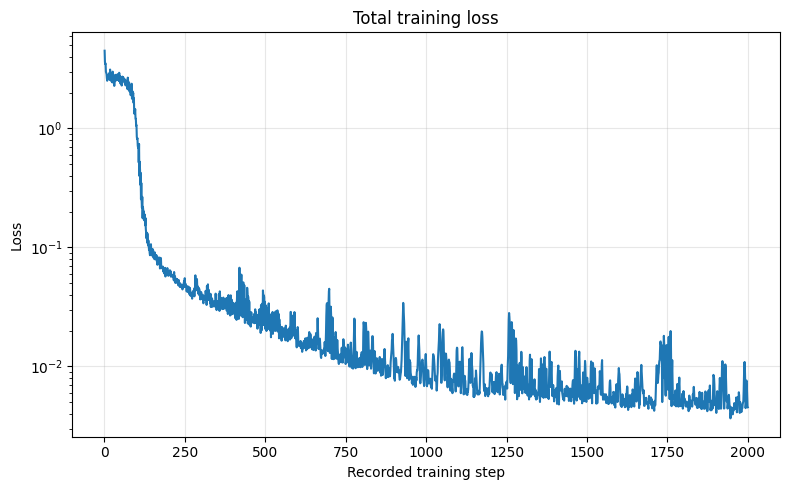

Saved: /kaggle/working/rheolnet_outputs/total_history.png


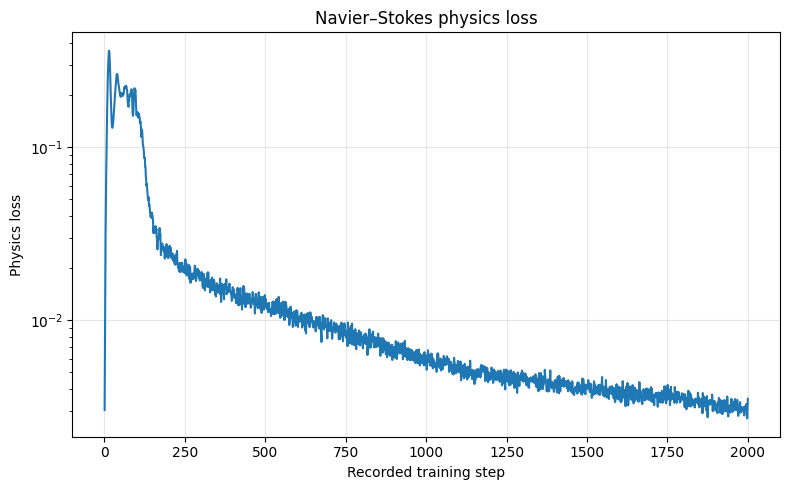

Saved: /kaggle/working/rheolnet_outputs/physics_history.png


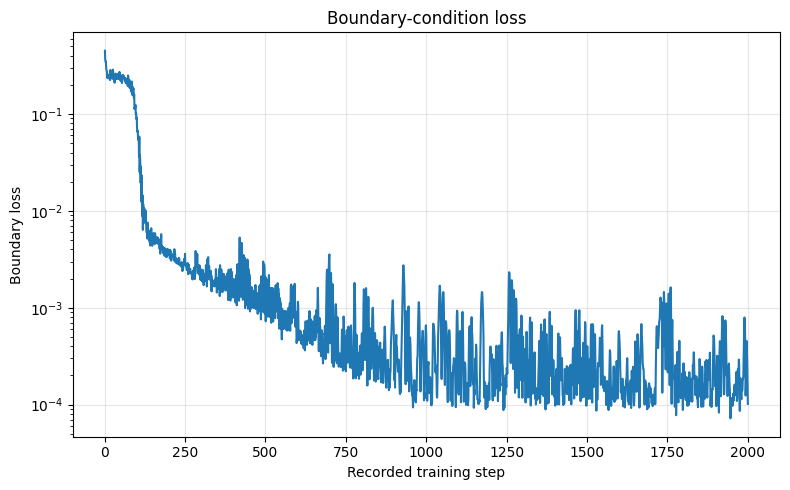

Saved: /kaggle/working/rheolnet_outputs/boundary_history.png


In [17]:
# ===============================================================
# LOSS PLOTS
# ===============================================================

OUTPUT_DIR = Path("/kaggle/working/rheolnet_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def plot_history_series(key, title, ylabel):
    values = history.get(key, [])

    if len(values) == 0:
        print(f"No history available for {key}.")
        return

    plt.figure(figsize=(8, 5))
    plt.semilogy(
        np.arange(1, len(values) + 1),
        values,
    )
    plt.xlabel("Recorded training step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = OUTPUT_DIR / f"{key}_history.png"
    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", save_path)


plot_history_series(
    "total",
    "Total training loss",
    "Loss",
)

plot_history_series(
    "physics",
    "Navier–Stokes physics loss",
    "Physics loss",
)

plot_history_series(
    "boundary",
    "Boundary-condition loss",
    "Boundary loss",
)

## Cell 16 — Residual diagnostics on fresh interior points

RMS residuals give a more interpretable PDE diagnostic than only viewing the scalar weighted loss.

FRESH-POINT PDE DIAGNOSTICS
RMS continuity : 2.734343e-02
RMS momentum x : 4.538932e-02
RMS momentum y : 1.486975e-02
eta min        : 1.384917e-02
eta max        : 5.476734e-02
gamma min      : 8.358081e-02
gamma max      : 3.757144e+00


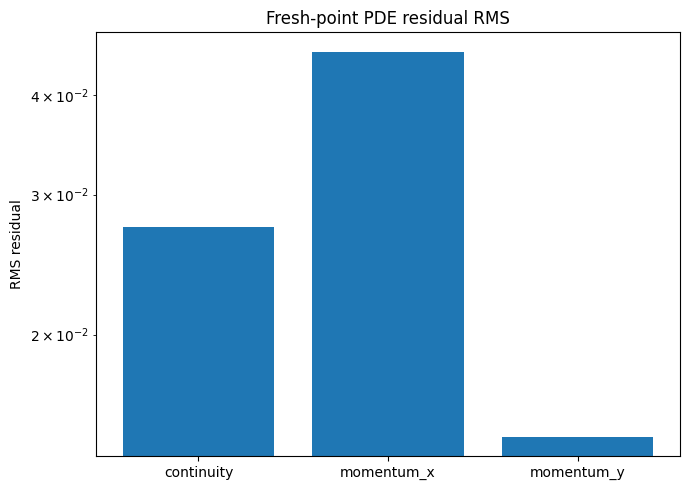

In [18]:
# ===============================================================
# RESIDUAL DIAGNOSTICS
# ===============================================================

model.eval()

xy_diag = sample_interior(2048)

(
    continuity_diag,
    momentum_x_diag,
    momentum_y_diag,
    eta_diag,
    gamma_diag,
) = compute_ns_residuals_nonnewtonian(
    model=model,
    xy=xy_diag,
    rho=cfg.rho,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)

rms_cont = torch.sqrt(
    torch.mean(continuity_diag.detach() ** 2)
).item()

rms_mx = torch.sqrt(
    torch.mean(momentum_x_diag.detach() ** 2)
).item()

rms_my = torch.sqrt(
    torch.mean(momentum_y_diag.detach() ** 2)
).item()

print("=" * 72)
print("FRESH-POINT PDE DIAGNOSTICS")
print("=" * 72)
print(f"RMS continuity : {rms_cont:.6e}")
print(f"RMS momentum x : {rms_mx:.6e}")
print(f"RMS momentum y : {rms_my:.6e}")
print(f"eta min        : {eta_diag.detach().min().item():.6e}")
print(f"eta max        : {eta_diag.detach().max().item():.6e}")
print(f"gamma min      : {gamma_diag.detach().min().item():.6e}")
print(f"gamma max      : {gamma_diag.detach().max().item():.6e}")
print("=" * 72)

plt.figure(figsize=(7, 5))
plt.bar(
    ["continuity", "momentum_x", "momentum_y"],
    [rms_cont, rms_mx, rms_my],
)
plt.yscale("log")
plt.ylabel("RMS residual")
plt.title("Fresh-point PDE residual RMS")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 17 — Velocity and pressure profiles across the channel

The cross-section is sampled at `x = 0.5`.

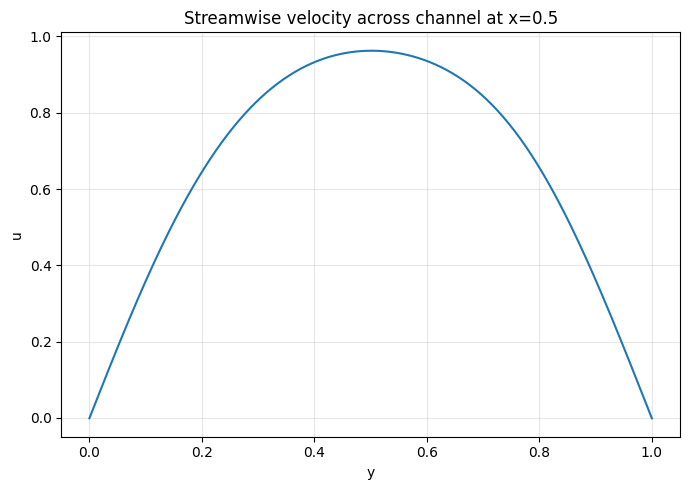

In [19]:
# ===============================================================
# CROSS-SECTION: u(y)
# ===============================================================

model.eval()

n_profile = 300

y_profile = torch.linspace(
    cfg.y_min,
    cfg.y_max,
    n_profile,
    device=device,
).reshape(-1, 1)

x_profile = torch.full_like(
    y_profile,
    0.5 * (cfg.x_min + cfg.x_max),
)

xy_profile = torch.cat(
    [x_profile, y_profile],
    dim=1,
)

with torch.no_grad():
    pred_profile = model(xy_profile)

u_profile = pred_profile[:, 0].cpu().numpy()
v_profile = pred_profile[:, 1].cpu().numpy()
p_profile = pred_profile[:, 2].cpu().numpy()
y_profile_np = y_profile[:, 0].cpu().numpy()

plt.figure(figsize=(7, 5))
plt.plot(y_profile_np, u_profile)
plt.xlabel("y")
plt.ylabel("u")
plt.title("Streamwise velocity across channel at x=0.5")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

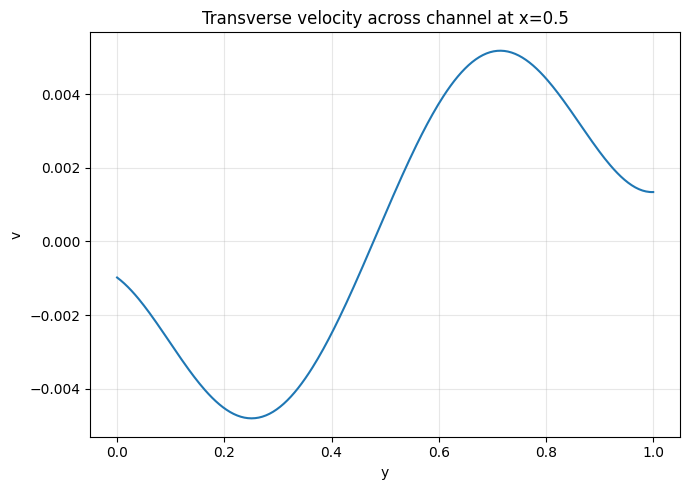

In [20]:
# ===============================================================
# CROSS-SECTION: v(y)
# ===============================================================

plt.figure(figsize=(7, 5))
plt.plot(y_profile_np, v_profile)
plt.xlabel("y")
plt.ylabel("v")
plt.title("Transverse velocity across channel at x=0.5")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

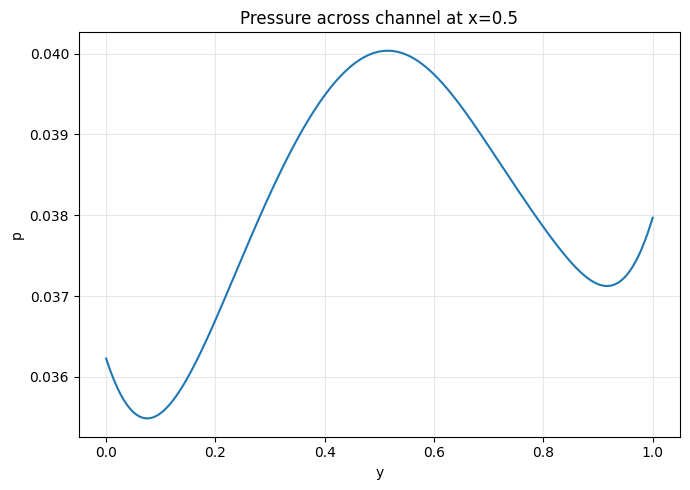

In [21]:
# ===============================================================
# CROSS-SECTION: p(y)
# ===============================================================

plt.figure(figsize=(7, 5))
plt.plot(y_profile_np, p_profile)
plt.xlabel("y")
plt.ylabel("p")
plt.title("Pressure across channel at x=0.5")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 18 — Task-required viscosity profile and shear-rate profile

This cell calls the imported Navier–Stokes residual again so that `eta` and `gamma_dot`
come from exactly the same code path used during training.

Expected shear-thinning behavior:

```text
higher shear
    ↓
lower local viscosity

lower shear
    ↓
higher local viscosity
```

CROSS-CHANNEL CY DIAGNOSTICS
Centre viscosity : 5.445101e-02
Bottom viscosity : 1.385970e-02
Top viscosity    : 1.385928e-02
Maximum shear    : 3.751413e+00
Minimum shear    : 9.429701e-02


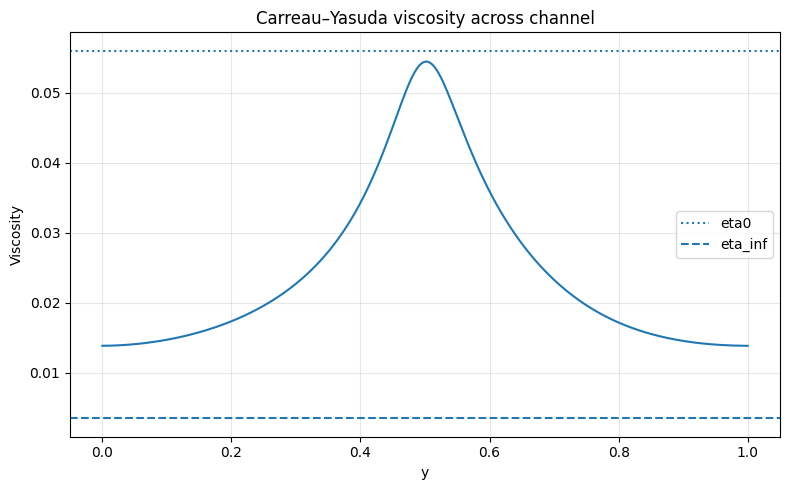

Saved: /kaggle/working/rheolnet_outputs/viscosity_day2.png


In [22]:
# ===============================================================
# VISCOSITY / SHEAR-RATE PROFILE
# ===============================================================

xy_profile_grad = (
    xy_profile
    .clone()
    .detach()
    .requires_grad_(True)
)

(
    continuity_profile,
    momentum_x_profile,
    momentum_y_profile,
    eta_profile,
    gamma_profile,
) = compute_ns_residuals_nonnewtonian(
    model=model,
    xy=xy_profile_grad,
    rho=cfg.rho,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)

eta_profile_np = (
    eta_profile
    .detach()
    .squeeze()
    .cpu()
    .numpy()
)

gamma_profile_np = (
    gamma_profile
    .detach()
    .squeeze()
    .cpu()
    .numpy()
)

print("=" * 72)
print("CROSS-CHANNEL CY DIAGNOSTICS")
print("=" * 72)
print(
    f"Centre viscosity : "
    f"{eta_profile_np[n_profile // 2]:.6e}"
)
print(
    f"Bottom viscosity : "
    f"{eta_profile_np[0]:.6e}"
)
print(
    f"Top viscosity    : "
    f"{eta_profile_np[-1]:.6e}"
)
print(
    f"Maximum shear    : "
    f"{gamma_profile_np.max():.6e}"
)
print(
    f"Minimum shear    : "
    f"{gamma_profile_np.min():.6e}"
)
print("=" * 72)

plt.figure(figsize=(8, 5))
plt.plot(
    y_profile_np,
    eta_profile_np,
)
plt.axhline(
    cfg.eta0,
    linestyle=":",
    label="eta0",
)
plt.axhline(
    cfg.eta_inf,
    linestyle="--",
    label="eta_inf",
)
plt.xlabel("y")
plt.ylabel("Viscosity")
plt.title("Carreau–Yasuda viscosity across channel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

viscosity_plot_path = (
    OUTPUT_DIR
    / "viscosity_day2.png"
)

plt.savefig(
    viscosity_plot_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Saved:", viscosity_plot_path)

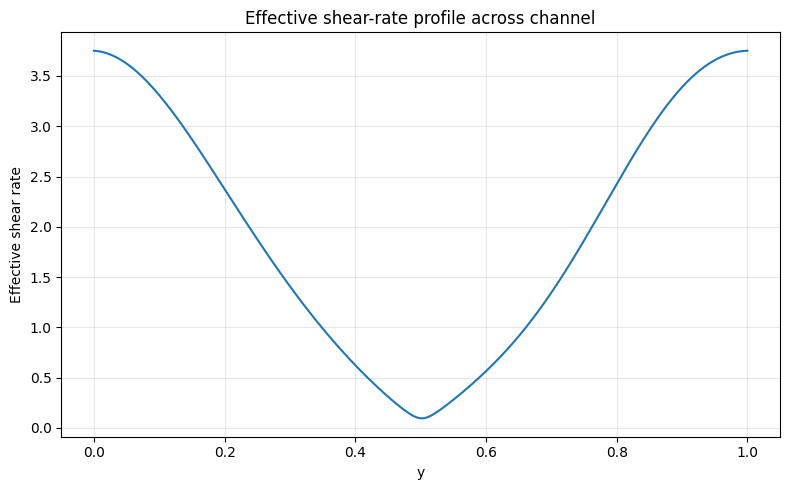

Saved: /kaggle/working/rheolnet_outputs/shear_rate_profile.png


In [23]:
# ===============================================================
# SHEAR-RATE PROFILE
# ===============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    y_profile_np,
    gamma_profile_np,
)
plt.xlabel("y")
plt.ylabel("Effective shear rate")
plt.title("Effective shear-rate profile across channel")
plt.grid(True, alpha=0.3)
plt.tight_layout()

shear_plot_path = (
    OUTPUT_DIR
    / "shear_rate_profile.png"
)

plt.savefig(
    shear_plot_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Saved:", shear_plot_path)

## Cell 19 — 2D field inspection

This is not required by Task 1.1, but it is valuable for spotting pathological PINN behavior that a
single centerline plot can hide.

A moderate grid is used because calculating non-Newtonian residuals requires autograd through the
stress field.

In [24]:
# ===============================================================
# 2D FIELD EVALUATION
# ===============================================================

model.eval()

n_grid = 60

x_grid = torch.linspace(
    cfg.x_min,
    cfg.x_max,
    n_grid,
    device=device,
)

y_grid = torch.linspace(
    cfg.y_min,
    cfg.y_max,
    n_grid,
    device=device,
)

Y, X = torch.meshgrid(
    y_grid,
    x_grid,
    indexing="ij",
)

xy_grid = torch.stack(
    [X.reshape(-1), Y.reshape(-1)],
    dim=1,
)

with torch.no_grad():
    pred_grid = model(xy_grid)

u_grid = (
    pred_grid[:, 0]
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

v_grid = (
    pred_grid[:, 1]
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

p_grid = (
    pred_grid[:, 2]
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

xy_grid_grad = (
    xy_grid
    .clone()
    .detach()
    .requires_grad_(True)
)

(
    _,
    _,
    _,
    eta_grid,
    gamma_grid,
) = compute_ns_residuals_nonnewtonian(
    model=model,
    xy=xy_grid_grad,
    rho=cfg.rho,
    eta0=cfg.eta0,
    eta_inf=cfg.eta_inf,
    lam=cfg.lam,
    n=cfg.n,
    a=cfg.a,
)

eta_grid_np = (
    eta_grid
    .detach()
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

gamma_grid_np = (
    gamma_grid
    .detach()
    .reshape(n_grid, n_grid)
    .cpu()
    .numpy()
)

extent = [
    cfg.x_min,
    cfg.x_max,
    cfg.y_min,
    cfg.y_max,
]

print("2D fields evaluated.")

2D fields evaluated.


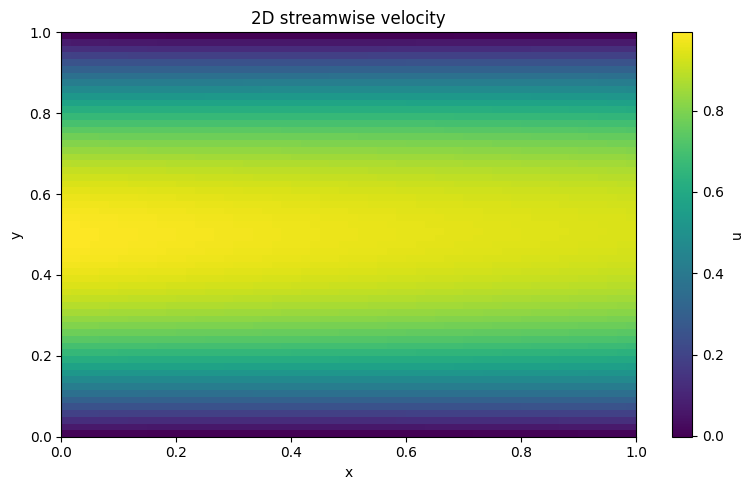

In [25]:
# ===============================================================
# 2D STREAMWISE VELOCITY
# ===============================================================

plt.figure(figsize=(8, 5))
img = plt.imshow(
    u_grid,
    origin="lower",
    extent=extent,
    aspect="auto",
)
plt.colorbar(img, label="u")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D streamwise velocity")
plt.tight_layout()
plt.show()

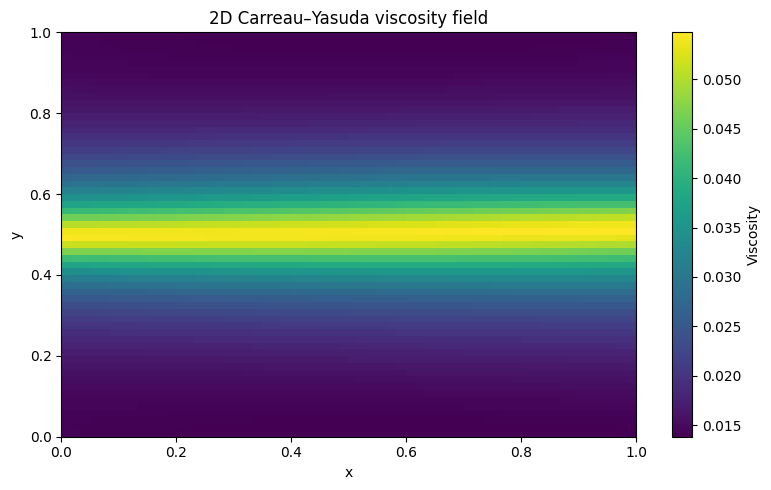

In [26]:
# ===============================================================
# 2D VISCOSITY
# ===============================================================

plt.figure(figsize=(8, 5))
img = plt.imshow(
    eta_grid_np,
    origin="lower",
    extent=extent,
    aspect="auto",
)
plt.colorbar(img, label="Viscosity")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Carreau–Yasuda viscosity field")
plt.tight_layout()
plt.show()

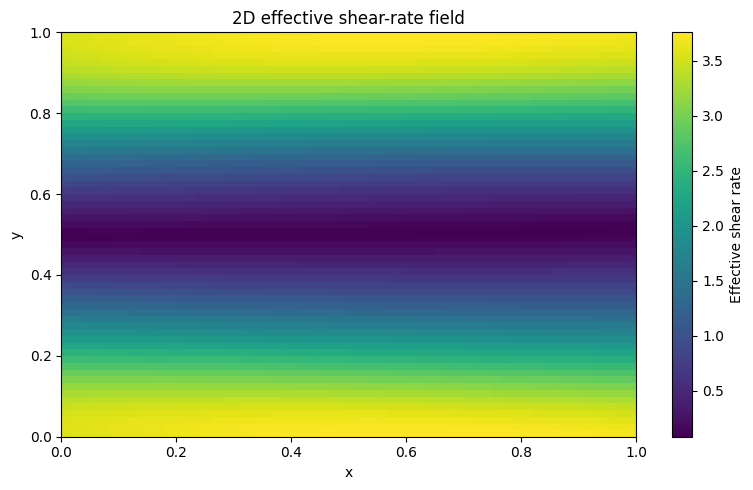

In [27]:
# ===============================================================
# 2D SHEAR RATE
# ===============================================================

plt.figure(figsize=(8, 5))
img = plt.imshow(
    gamma_grid_np,
    origin="lower",
    extent=extent,
    aspect="auto",
)
plt.colorbar(img, label="Effective shear rate")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D effective shear-rate field")
plt.tight_layout()
plt.show()

## Cell 20 — Automated tests

For Task 1.1, the repository should contain:

```text
physics/tests/test_carreau_yasuda.py
physics/tests/test_navier_stokes_nonnewtonian.py
```

The second test should check the non-Newtonian residual itself, not only the viscosity function.

In [28]:
# ===============================================================
# PYTEST
# ===============================================================

import subprocess
import sys

test_files = [
    REPO_DIR / "physics" / "tests" / "test_carreau_yasuda.py",
    REPO_DIR / "physics" / "tests" / "test_navier_stokes_nonnewtonian.py",
]

missing_tests = [
    str(path)
    for path in test_files
    if not path.exists()
]

if missing_tests:
    print("Missing test files:")
    for path in missing_tests:
        print("  -", path)

    raise FileNotFoundError(
        "Task 1.1 tests are incomplete."
    )

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        str(test_files[0]),
        str(test_files[1]),
        "-q",
    ],
    cwd=str(REPO_DIR),
    text=True,
)

if result.returncode != 0:
    raise RuntimeError(
        "One or more Task 1.1 tests failed."
    )

print("✓ Task 1.1 tests passed")

.............                                                            [100%]
13 passed in 2.48s
✓ Task 1.1 tests passed


## Cell 21 — Automatic Task 1.1 status report

This checks the software artifacts and the notebook outputs that can be verified automatically.

It does **not** replace scientific validation against CFD or a trusted reference solution.

In [29]:
# ===============================================================
# TASK 1.1 CHECKLIST
# ===============================================================

navier_file = (
    REPO_DIR
    / "physics"
    / "navier_stokes.py"
)

test_ns_file = (
    REPO_DIR
    / "physics"
    / "tests"
    / "test_navier_stokes_nonnewtonian.py"
)

sig = inspect.signature(
    compute_ns_residuals_nonnewtonian
)

params = set(sig.parameters)

checks = {
    "physics/navier_stokes.py exists":
        navier_file.exists(),

    "Residual receives model":
        "model" in params,

    "Residual receives xy":
        "xy" in params,

    "CY viscosity function imports":
        callable(carreau_yasuda_viscosity),

    "Physics loss function imports":
        callable(navier_stokes_physics_loss),

    "Non-Newtonian NS test file exists":
        test_ns_file.exists(),

    "Viscosity profile was generated":
        (OUTPUT_DIR / "viscosity_day2.png").exists(),
}

print("=" * 78)
print("TASK 1.1 — SOFTWARE COMPLETION CHECK")
print("=" * 78)

for item, passed in checks.items():
    symbol = "✅" if passed else "❌"
    print(f"{symbol} {item}")

all_passed = all(checks.values())

print("-" * 78)

if all_passed:
    print("✅ Task 1.1 software integration checks are complete.")
else:
    print("❌ Some Task 1.1 software checks are still incomplete.")

print()
print(
    "Scientific validation is a separate next step: "
    "compare the trained non-Newtonian solution against a trusted "
    "CFD/reference solution using a consistent dimensional or "
    "nondimensional formulation."
)
print("=" * 78)

TASK 1.1 — SOFTWARE COMPLETION CHECK
✅ physics/navier_stokes.py exists
✅ Residual receives model
✅ Residual receives xy
✅ CY viscosity function imports
✅ Physics loss function imports
✅ Non-Newtonian NS test file exists
✅ Viscosity profile was generated
------------------------------------------------------------------------------
✅ Task 1.1 software integration checks are complete.

Scientific validation is a separate next step: compare the trained non-Newtonian solution against a trusted CFD/reference solution using a consistent dimensional or nondimensional formulation.


## Cell 22 — Optional Git workflow helper

Keep `PULL_NOW=False` during a normal run.

When you push updated `.py` files from your local machine to GitHub, set it to `True` once to pull
the newest branch into Kaggle. Because autoreload is enabled, subsequent notebook calls should use
the updated modules.

If imports behave strangely after a major class/module rewrite, restart the kernel.

In [ ]:
# ===============================================================
# OPTIONAL GIT REFRESH
# ===============================================================

PULL_NOW = False

if PULL_NOW:
    subprocess.check_call(
        ["git", "pull", "origin", BRANCH],
        cwd=str(REPO_DIR),
    )

    print("Latest branch changes pulled.")
    print(
        "If you changed class definitions substantially, "
        "restart the kernel before continuing."
    )
else:
    print("Git pull skipped.")

# What the results mean

## When Task 1.1 is genuinely integrated

You should be able to say:

> The PINN training residual now computes the local strain/shear rate from the predicted velocity
> field, evaluates Carreau–Yasuda viscosity at each collocation point, forms the non-Newtonian
> viscous stress, differentiates that stress through autograd, and uses the resulting continuity
> and x/y momentum residuals directly in the physics loss.

That is much stronger than:

> "I trained a Newtonian PINN and plotted CY viscosity afterward."

The latter is only post-processing. This notebook is structured to use CY **inside training**.

---

## What this notebook proves

If the smoke test, training, plots, and unit tests all pass, you have strong evidence that:

- the `.py` modules are actually being imported;
- the model is on the GPU;
- the CY function is differentiable in the residual path;
- local viscosity and shear rate are being produced during training;
- both momentum residuals and continuity are part of the objective;
- checkpoints can be resumed safely;
- the required viscosity profile can be generated;
- the test file is present and runnable.

---

## What this notebook does **not** prove yet

It does not by itself prove that RheolNet predicts physiologically accurate blood flow.

For publication-quality validation, the later experiment should use:

1. consistent SI units **or** a carefully derived nondimensional formulation;
2. realistic geometry and boundary conditions;
3. a reference solution from CFD / FEM / a trusted benchmark;
4. quantitative error metrics, not only plots;
5. mesh/reference convergence checks where appropriate.

That is the next scientific-validation layer after Task 1.1 software integration.